SWMAL

Assignment 4

Group members: 

Nilas Lorenzen (202307961), Peter Fabiansen (202305295), Rasmus Møller (202305159)


\newpage

# Reseach question
This report aims to build a model with the abilty to both determine whether or not, there is a fault in the bluetooth and/or wifi antenna system, and if there is, what type of fault is present. 
For the O4 project we have chosen to investigate the reliabilty of flexible and wearable antennas. Our goal will be to develop a machine learning model able to predict imminent fault cases and be a part of the maintenance and detection system. The machine learning model should be a classifier able to ascertain whether or not the wifi and or bluetooth is failing and also classify which kind of fault is present. 

# Dataset
To train our model we have chosen [This data set from kaggle.com](https://www.kaggle.com/datasets/amineipad/antenna-performance-and-fault-detection-dataset?fbclid=IwY2xjawQffuJleHRuA2FlbQIxMQBzcnRjBmFwcF9pZAEwAAEeJ2UxEK4SsTF78Us3f-ALRqmDz68CFkv2aszLsnn0NTB3mq0-Kfri-Ghet-M_aem_khEFRjyx4IXRwn4GQIPcEw), it should work well due to its comprehensive feature list and a sample size of 2687, which is much more than is stated on the website, but is the true value of samples. The features include Length, Width, Height, Permittivity, Conductivity, and epsilon_r. Alongside these physical traits, the dataset captures critical radio frequency (RF) performance indicators like Return Loss (S11), Voltage Standing Wave Ratio (VSWR), Gain, Efficiency, and Bandwidth. From the description of the dataset: "Crucially, the dataset features explicit classifications for various environmental and physical fault conditions—such as Humidity/Sweat, Bending, Cracks, and Rupture/Coupure—and tracks their impact on the operational status of both WiFi and BT functionalities. It is an excellent resource for predictive maintenance, anomaly detection, and robust wearable antenna design using machine learning." Furthermore we as a group hope this project will enable us to obtain a deeper understanding of antenna perfomance and the parameters related to this. The data in this set was "collected through a series of controlled simulations and empirical measurements that emulate real-world conditions for wearable antennas. Various physical deformations and environmental stressors were applied to the antenna models, including bending at different radii, introducing structural cracks or ruptures, and simulating changes in dielectric properties due to humidity or sweat." So we should have in mind that the data probably represents cleaner versions of the faults and is limited to these kinds of fault, not entirely covering the real world in which the wearable antennas would exist. First, lets prepare the data for our model.

   Length  Width  Height  Permittivity  Conductivity  Bend   Feed    S11  \
0   46.72  38.62    1.46          1.51      12210.65  0.56 -10.27  -7.09   
1   40.32  36.17    1.30          1.61       9589.73  0.48 -17.33  -7.92   
2   43.84  35.89    1.17          1.53       4067.44  0.99 -11.95 -18.97   
3   43.77  39.46    1.26          1.88      13052.58  0.67 -10.07 -12.89   
4   46.48  39.66    1.30          2.44      12682.11  1.08 -17.57 -22.94   

   VSWR  Gain  Efficiency  Bandwidth       WiFi Fault        BT Fault  \
0  3.41  5.09       62.26     102.74           Cracks          Cracks   
1  2.47  5.17       66.61      96.06  Rupture_Coupure        No_Fault   
2  3.20  5.07       83.42     150.03          Bending  Strong_Flexion   
3  1.72  3.83       42.22      54.23      Body_Effect         Coupure   
4  1.44  3.48       77.39      93.00   Strong_Flexion        No_Fault   

  WiFi Status BT Status  epsilon_r  
0       Fault     Fault       3.90  
1       Fault    Normal       

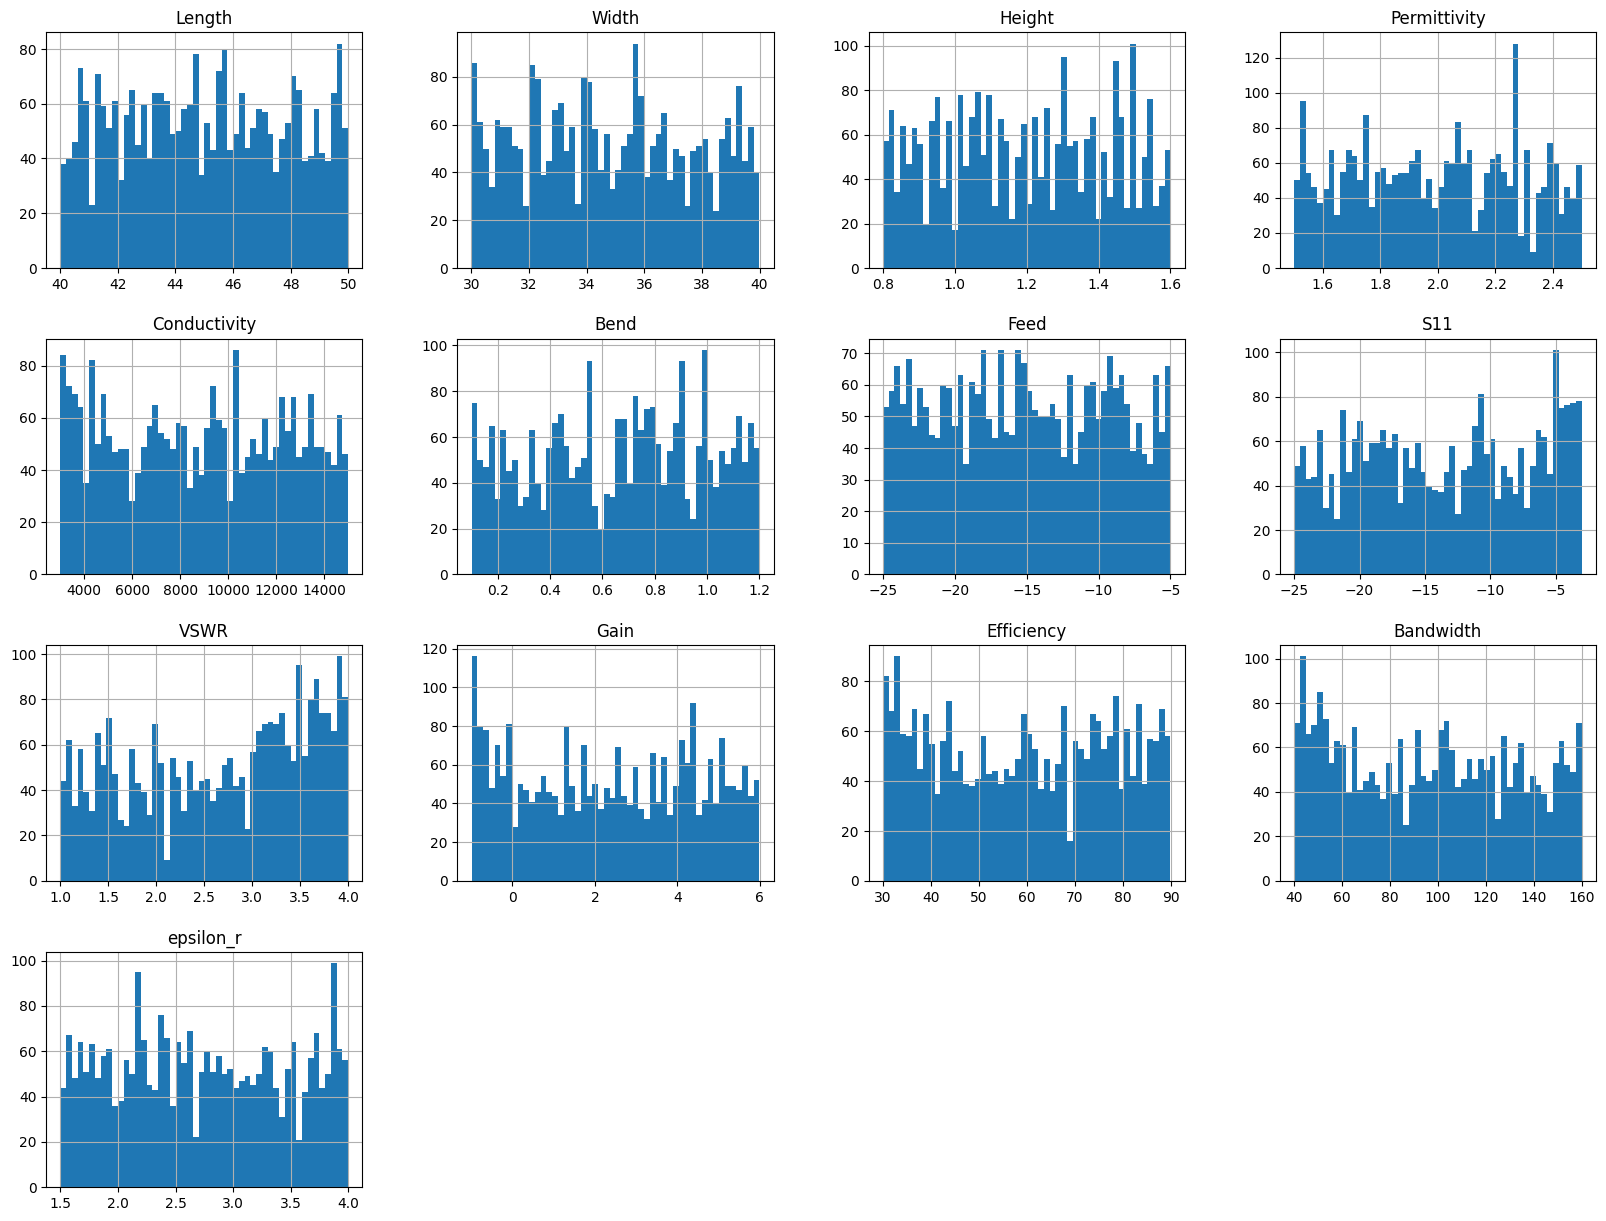

In [4]:
# Importing the data
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import validation_curve, KFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import jaccard_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
import os
import seaborn as sns

# Load the data into a DataFrame
Bat_dat = "antenna_fault.csv"
df = pd.read_csv(Bat_dat)

print(df.head()) #Prints the first five rows to get an idea of how the dataset looks
print(df.info()) #Prints some infomation about the data and their type (String/float)
print(df.describe()) #Prints count, mean, standard deviation, and the quatiles for each feature
df.hist(bins=50, figsize=(20,15))
plt.show()

The dataset contains both data regarding whether there is a fault in the wifi or bluetooth along with which type of fault it is as 4 seperate features. This project focuses on classifying the type of fault which is present, including no_fault as a class for both wifi and bluetooth thereby also classying whether there is a fault at all. Because of this, the columns depicting the whether there is a fault will be dropped from the features to avoid leaking the anwers. 

   Length  Width  Height  Permittivity  Conductivity  Bend   Feed    S11  \
0   46.72  38.62    1.46          1.51      12210.65  0.56 -10.27  -7.09   
1   40.32  36.17    1.30          1.61       9589.73  0.48 -17.33  -7.92   
2   43.84  35.89    1.17          1.53       4067.44  0.99 -11.95 -18.97   
3   43.77  39.46    1.26          1.88      13052.58  0.67 -10.07 -12.89   
4   46.48  39.66    1.30          2.44      12682.11  1.08 -17.57 -22.94   

   VSWR  Gain  Efficiency  Bandwidth       WiFi Fault        BT Fault  \
0  3.41  5.09       62.26     102.74           Cracks          Cracks   
1  2.47  5.17       66.61      96.06  Rupture_Coupure        No_Fault   
2  3.20  5.07       83.42     150.03          Bending  Strong_Flexion   
3  1.72  3.83       42.22      54.23      Body_Effect         Coupure   
4  1.44  3.48       77.39      93.00   Strong_Flexion        No_Fault   

   epsilon_r  
0       3.90  
1       3.03  
2       3.65  
3       3.51  
4       2.06  


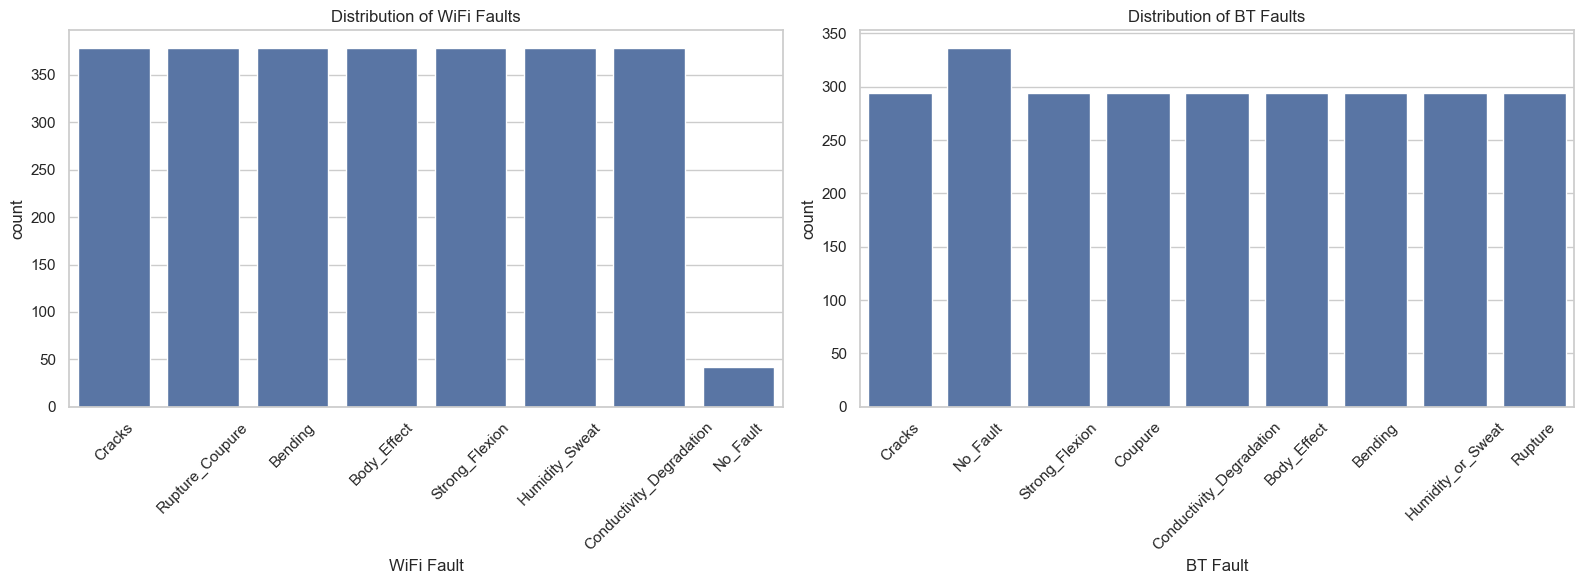

In [5]:
# Removing the wifi status and Bluetooth status columns to avoid leaking the answers
# Drop columns at index 14 and 15
ds = df.drop(df.columns[[14, 15]], axis=1)
print(ds.head())

# Visualize the fault types
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# WiFi Fault Count
sns.countplot(data=df, x='WiFi Fault', ax=axes[0])
axes[0].set_title('Distribution of WiFi Faults')
axes[0].tick_params(axis='x', rotation=45) # Rotate labels so they don't overlap

# BT Fault Count
sns.countplot(data=df, x='BT Fault', ax=axes[1])
axes[1].set_title('Distribution of BT Faults')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Choice of ML algorithm
We have chosen to focus our efforts on the random forest classifier, based on good past experiences combining fast computation times with good results. Further more we asses the random forest model to be well equipped for multi label, multi output data, which is what we are dealing with. In fact the rfc does not require any parameters or data preprocessing to accept this data set. We have chosen to work with random_state=42 for all iterations to make the study reproducable. Given that the dataset comes with the true fault categories we are in the realm of supervised learning and  multi-output classification as we want to figure out what fault type is present based on the features given. We chose rfc because it handles both numerical and categorical data well, requires minimal feature scaling, and is excellent at capturing non-linear relationships. Furthermore the rfc is much more robust than the single tree classifiers since it is the average of multiple models. On the other side the rfc is prone to overfitting and learning the noise from the dataset aswell so this must be kept in mind when tuning. To further confirm this notion, we later test a couple of other models.

# Preprocessing
From the bar charts above it is obvious that the model might run into problems detecting the wifi fault: No_Fault, with only 43 instances, because of this it would be a good idea to use the class_weight='balanced' parameter for the model, to tell the model to pay extra atention to the smaller fault bar. Other than the Wifi no fault the fault types are quite evenly dispersed.

Since the length, width and height are known it is possible to calculate the volume which might be a defining feature, this is done in the following code. After the feature has been introduced, it would be interesting to see how it correlates to each of the fault types, since one fault type isn't "more" than another, one-hot encoding is used as described in HOML p. 116, this will create one binary attribute per category, this will result in a large matrix with a single 1 on the row and 0s for the other fault types.

The volume-height correlation is quite high, but not too high, there is still 13%, not correlated, this is okay, and since we got approx. 1% better accuracy, we chose to keep the volume feature.

As seen below, the dataset is first split into X and y matrices then split again into a training set and test set, setting aside $20\%$ for testing. Not only do we set aside 20\% we also ask the scikit learn function train_test_split to stratify with respect to the y data ensuring that even if the collecters of data has sorted the faults, this will not impact the training. Luckily they have not, but better to be too robust than fragile. If there were entries missing we would have to decide whether to fill them in with the mean or median of the other values or complety scrap either the feature(s) or the lacking samples. 

In [6]:
# Adding a volume feature to the df dataset
df['Volume'] = df.iloc[:, 0] * df.iloc[:, 1] * df.iloc[:, 2]

# creating an encoded "dummy" dataset with 1s and 0s
df_encoded = pd.get_dummies(df, columns=['WiFi Fault', 'BT Fault'])

# Calculate correlation on the new numeric-only dataframe
corr_matrix = df_encoded.corr(numeric_only=True)

print(corr_matrix["Volume"].sort_values(ascending=False))

# Splitting the data into features and target categories
target_cols = ['WiFi Fault', 'BT Fault']
y = ds[target_cols].copy()
X = ds.drop(target_cols, axis=1)

# Splitting into train and test sets, using stratify parameter for the y to ensure uniform distribution of faults
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y 
)
print("X_train")
print(X_train.head())
print("y_train")
print(y_train.head())

target_encoder = OrdinalEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
print("y_train_encoded")
print(y_train_encoded[:,1])

Volume                                 1.000000
Height                                 0.874475
Width                                  0.405628
Length                                 0.324065
WiFi Fault_Rupture_Coupure             0.067342
WiFi Fault_No_Fault                    0.065602
BT Fault_Humidity_or_Sweat             0.045578
Feed                                   0.045561
Efficiency                             0.040558
BT Fault_No_Fault                      0.023509
Gain                                   0.022870
BT Fault_Cracks                        0.021201
BT Fault_Body_Effect                   0.019541
BT Fault_Rupture                       0.019530
WiFi Fault_Humidity_Sweat              0.018205
WiFi Fault_Body_Effect                 0.012386
epsilon_r                              0.009797
Conductivity                           0.007284
VSWR                                  -0.002347
WiFi Fault_Strong_Flexion             -0.009212
WiFi Fault_Conductivity_Degradation   -0

# Training and testing
Training the Random forest classifier to test on the test-set. We expect to measure the goodness of the model using, accuracy, Jaccard score aswell as the F1 score to evalute the model. Allowing for a range from simple criterias to a deeper look at how well the model has learned. 

In [7]:
# Initiating the classifier
forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(X_train, y_train)
y_pred = forest_clf.predict(X_test)

print(y_test.shape)
print(y_pred.shape)

X_test_np = np.array(X_test)
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)
y_pred_np = np.array(y_pred)

# Flatten to 1D
X_test_flat = X_test_np.ravel()
X_train_flat = X_train_np.ravel()
y_train_flat = y_train_np.ravel()
y_test_flat = y_test_np.ravel()
y_pred_flat = y_pred_np.ravel()


acc_score = accuracy_score(y_test_flat, y_pred_flat)
print(f"Accuracy Score: {acc_score:.4f}")

j_score = jaccard_score(y_test_flat, y_pred_flat, average='weighted')
print(f"Jaccard Score: {j_score:.4f}")

(538, 2)
(538, 2)
Accuracy Score: 0.8792
Jaccard Score: 0.7873


To confirm that the Random Forest Classifier is the right model to use, we try to test a couple of other models to compare the scores. These models included the ExtraTreesClassifier model, which is much like the RandomForestClassifier but with extra randomness and the LinearSVC model. 

The results are shown below. From these results it can be seen that the ExtraTreesClassifier is slighly worse while the LinearSVC model is much worse. Based on this, it does not make sense to switch the model and the project is continued with the RandomForestClassifier.

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
ETC_model = ExtraTreesClassifier(random_state=42)
ETC_model.fit(X_train, y_train)
y_pred = ETC_model.predict(X_test)

y_test_np = np.array(y_test)
y_pred_np = np.array(y_pred)
y_test_flat = y_test_np.ravel()
y_pred_flat = y_pred_np.ravel()


ETC_acc_score = accuracy_score(y_test_flat, y_pred_flat)
print(f"Accuracy Score: {ETC_acc_score:.4f}")
ETC_j_score = jaccard_score(y_test_flat, y_pred_flat, average='weighted')
print(f"Jaccard Score: {ETC_j_score:.4f}")

Accuracy Score: 0.8875
Jaccard Score: 0.7984


In [9]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.svm import LinearSVC
SVC_model = MultiOutputClassifier(LinearSVC(random_state=42))
SVC_model.fit(X_train, y_train)
y_pred = SVC_model.predict(X_test)

y_test_np = np.array(y_test)
y_pred_np = np.array(y_pred)
y_test_flat = y_test_np.ravel()
y_pred_flat = y_pred_np.ravel()


SVC_acc_score = accuracy_score(y_test_flat, y_pred_flat)
print(f"Accuracy Score: {SVC_acc_score:.4f}")
SVC_j_score = jaccard_score(y_test_flat, y_pred_flat, average='weighted')
print(f"Jaccard Score: {SVC_j_score:.4f}")

Accuracy Score: 0.2128
Jaccard Score: 0.1021


## Score Functions
We have chosen to test our models against three different score functions, the accuracy score, the Jaccard score, and the F1 score. The accuracy being fairly well known at this point, it simply calculates the amount of correct predictions out of the total amount of predictions as a percentage. For a multi label multi output problem however, it fails to consider the importance of having both predictions per instance correct, which is why we have later tested using the exact pair accuracy, which only consideres the output correct, if both predictions are correct. Beyond accuracy we also implemented the Jaccard score as a metric, which more heavily punishes wrong predictions and is calculated as the intersection over union, and so better considers the importance of getting both predictions correct. The Jaccard score is calculated as:
$$
J = \frac{TP}{TP + FP + FN}
$$
or logically as
$$
J(A,B) = \frac{|A \cap B|}{|A \cup B|}
$$
We previously also included the F1 score, see poster, but after further reading have realized that for multi label problems the F1 score becomes basically identical to the accuracy calculation and has subsequentially been removed. 

## Loss Function
For this project, a random forest classifier is used which, unlike logistic regression models and neural networks, does not optimize a global loss function. The random forest classifier instead works based on decision tress, which chooses to split based on an impurity criterion. By default, the criterion in Scikit learn is the Gini impurity. Another option is Entropy, which will be attempted under hyperparameter optimization. 

An impurity criterion can be understood as the rule that decides how good a split would become. The criterion ensures that the trees chooses splits which reduces the impurity as much as possible. A node is in this case considered pure if all samples in it belongs to the same class. The tree thus considered whether splitting will results in a more class-pure child node which is decided by the impurity criterion.

Gini impurity specifically, measures how often a randomly chosen sample, from the considered node, would be misclassified if it was labelled randomly according to the distribution of the node. So for a node containing only class A, there would be no chance of misclassification and it would be considered totally pure. It can be written mathematically as (From Scikit-learn):

\begin{equation*}
\mathrm{Gini} = \sum_{k=1}^{K} p_k(1-p_k)
\end{equation*}
Where $p_k$ is the probability of a sample belonging to class $k$ within a specific node, calculated by:
\begin{equation*}
p_k = \frac{\text{number of samples of class } k}{\text{total number of samples in the node}}
\end{equation*}
Entropy, on the other hand, measures uncertainty, where a pure node has no uncertainty and a mixed node has a high uncertainty. Mathematically:
\begin{equation*}
\mathrm{Entropy} = -\sum_{k=1}^{K} p_k \log(p_k)
\end{equation*}

The tree then compares impurity before and after a possible split and chooses the one with the largest possible decrease in impurity. The random forest classifier is thus optimized based on purity instead of a loss function.

Since there is neither loss nor epochs when training a random forest classifier, there is also no loss vs epoch learning curve. A random forest classifier can, however, still have a learning curve measuring either performance vs training set size, performance vs number of trees or performance vs other hyperparameters. In the following, several of these learning curves are plotted.

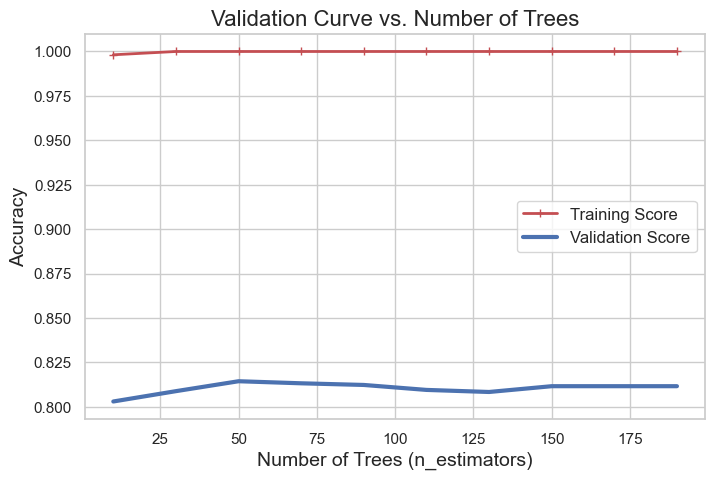

In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_range = np.arange(10, 200, 20) # Tests 10, 30, 50... trees

from sklearn.metrics import make_scorer
import numpy as np

# Define a custom scoring function that handles the 2D arrays
# This calculates the percentage of all individual labels that are correct AKA. accuracy
def All_D_accuracy(y_true, y_pred):
    return np.mean(np.array(y_true) == np.array(y_pred))

# Wrap it in make_scorer
custom_scorer = make_scorer(All_D_accuracy)

# Using validation_curve from scikit learn
train_scores, val_scores = validation_curve(
    forest_clf,
    X_train,
    y_train_encoded,
    param_name="n_estimators",
    param_range=param_range,
    cv=kf,
    scoring=custom_scorer,
    error_score="raise"
)

# Calculate the mean across all 5 cross-validation folds
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(param_range, train_scores_mean, "r-+", linewidth=2, label="Training Score")
plt.plot(param_range, val_scores_mean, "b-", linewidth=3, label="Validation Score")

plt.xlabel("Number of Trees (n_estimators)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.title("Validation Curve vs. Number of Trees", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

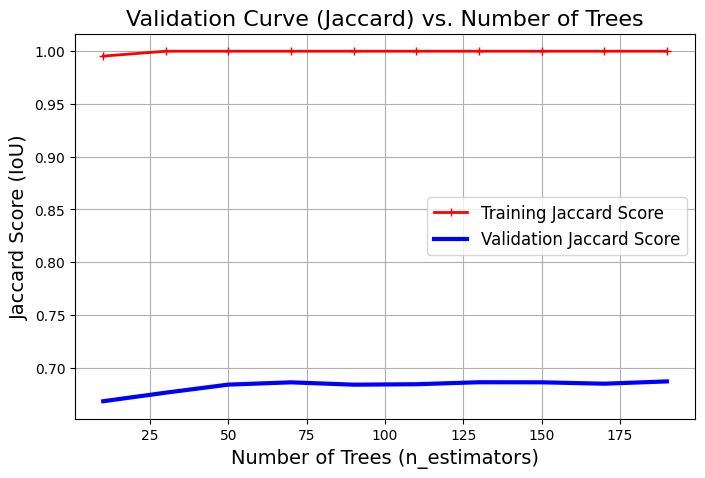

In [32]:
def custom_jaccard_scorer(y_true, y_pred):
    y_true_flat = np.array(y_true).flatten()
    y_pred_flat = np.array(y_pred).flatten()
    return jaccard_score(y_true_flat, y_pred_flat, average='weighted')

# Wrap it for scikit-learn
jaccard_custom = make_scorer(custom_jaccard_scorer)

train_scores, val_scores = validation_curve(
    forest_clf,
    X_train,
    y_train_encoded,
    param_name="n_estimators",
    param_range=param_range,
    cv=kf,
    scoring=jaccard_custom,
    error_score="raise"
)

# Calculate Means
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(param_range, train_scores_mean, "r-+", linewidth=2, label="Training Jaccard Score")
plt.plot(param_range, val_scores_mean, "b-", linewidth=3, label="Validation Jaccard Score")

plt.xlabel("Number of Trees (n_estimators)", fontsize=14)
plt.ylabel("Jaccard Score (IoU)", fontsize=14)
plt.title("Validation Curve (Jaccard) vs. Number of Trees", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# Validation before tuning hyperparameters
As seen above, letting all hyperparameters of the Randon Forest Classifier remain as standard values leads to a severe case of overfitting, although it does return a non-horrible validation accuracy, we see it even clearer when applying the jaccard score, which more heavily punishes the model for not having both predictions correct. In fact we see that already at n_estimators = 10 the model has perfectly learned all of the training data, as well as the noise. Below the accuracy score has been plotted for 10 estimators and varying depth. Aiming to expose the impact of both n_estimators as well as depth.

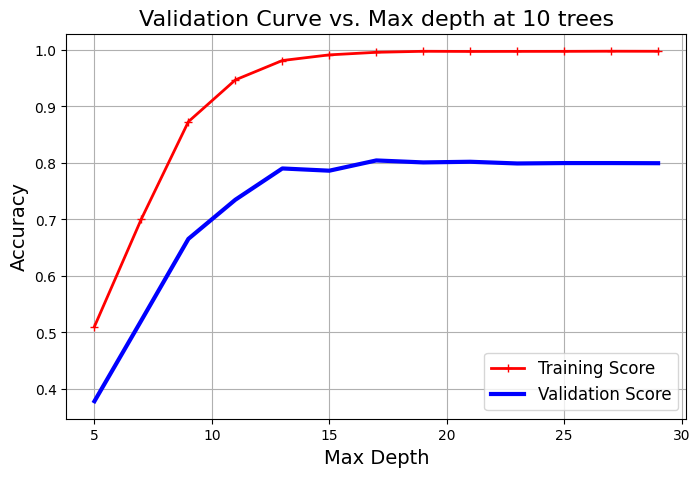

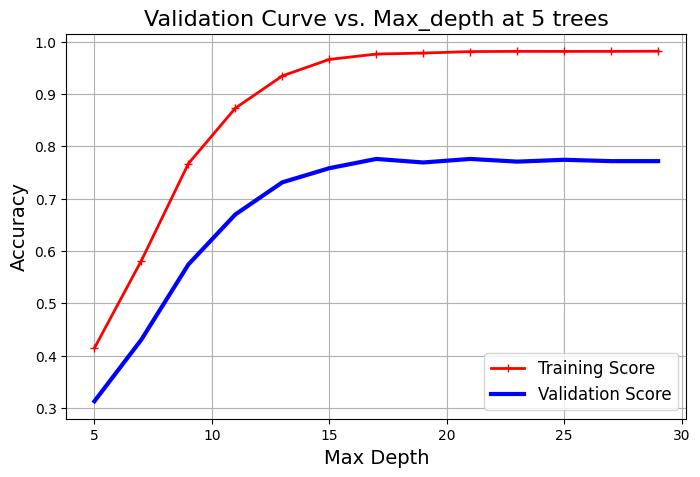

In [33]:
depth_range = np.arange(5, 30, 2)

forest_clf_n10 = RandomForestClassifier(n_estimators=10, random_state=42)

forest_clf_n5 = RandomForestClassifier(n_estimators=5, random_state=42)

train_scores, val_scores = validation_curve(
    forest_clf_n10,
    X_train,
    y_train_encoded,
    param_name="max_depth",
    param_range=depth_range,
    cv=kf,
    scoring=custom_scorer,
    error_score="raise"
)

# Calculate the mean across all 5 cross-validation folds
train_scores_mean_n10 = np.mean(train_scores, axis=1)
val_scores_mean_n10 = np.mean(val_scores, axis=1)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(depth_range, train_scores_mean_n10, "r-+", linewidth=2, label="Training Score")
plt.plot(depth_range, val_scores_mean_n10, "b-", linewidth=3, label="Validation Score")

plt.xlabel("Max Depth", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.title("Validation Curve vs. Max depth at 10 trees", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


train_scores, val_scores = validation_curve(
    forest_clf_n5,
    X_train,
    y_train_encoded,
    param_name="max_depth",
    param_range=depth_range,
    cv=kf,
    scoring=custom_scorer,
    error_score="raise"
)

# Calculate the mean across all 5 cross-validation folds
train_scores_mean_n5 = np.mean(train_scores, axis=1)
val_scores_mean_n5 = np.mean(val_scores, axis=1)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(depth_range, train_scores_mean_n5, "r-+", linewidth=2, label="Training Score")
plt.plot(depth_range, val_scores_mean_n5, "b-", linewidth=3, label="Validation Score")

plt.xlabel("Max Depth", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.title("Validation Curve vs. Max_depth at 5 trees", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# Overfitting and underfitting
In a Random Forest Classifier overfitting and underfitting mostly relates to how complex the individual tress are allowed to become.

The model naturally reduces overfitting by averaging across trees but this does not make it impossible. Overfitting can still occur if the hyperparameters allow the trees to grow very large.

Overfitting means the forest learns the training data too specifically. The learnings curves show some degree of this, since they show the typical pattern of overfitting where the train accuracy approaches 1 while the valdiation accuracy is much lower. It can, however, not be directly compared since it is not the typical score vs epoch learning curves but the general pattern where gap between training score and validation score increases due to increased complexity of the trees can still be seen. This can happen with the standard hyperparameter for the Random Forest model because it has max_depth=None, min_samples_leaf=1, min_samples_split=2, which places not restriction on how complex the tress are allowed to get, allowing for very deep and detailed trees.

Deep and complex trees allows each tree to learn small, noisy patterns in the training data. Despite the forest average reducing this effect, if the trees are too flexible, this still result in overfitting. 

Underfitting on the other hand, means the forest is too simple to learn the real pattern in the data. This is usually shown by all the scoring being low. An example of this can be seen by looking at the scores from the Linear SVC model under training and testing. In random forests, underfitting usually happens when the trees are restricted too much, for example if the max_depth is too low along with min_samples_leaf and min_samples split being too high. 

To prevent both of these, the hyperparameter space is investigated next section where restrictions is placed on the hyperparameters and the best resulting model is afterwards considered.

## Optimization of Hyperparameters
To improve the model performance, a search of the hyperparameter space is performed. In this case a very thorough search using 7 hyperparameters is performed to ensure a good final performance. The hyperparameters to be considered for the Random Forest Classfier is:

'n_estimators': The number of decision trees in the forest. For classfication, each tree votes for a certain class and the majority then decides the prediction. More trees usually improves prediction. In this case, the following are tried: $[200, 400, 600, 800, 1000]$

'max_depth': How complex or deep the trees are allowed to get. The depth of a tree describes the longest path from the root note to a leaf node. Too deep can results in overfitting. Considered depths: $[None, 10, 20, 40, 60, 80, 100]$ Note that None means the trees are expanded until pure or until all leaves contain less than 'min_samples_split'. 

'min_samples_split': The minimum number of samples required for a tree node to decide to split. Considered splits: $[2, 5, 10, 20]$

'min_samples_leaf': The minimum required training samples in a leaf node which controls how general the model becomes. A higher number prevents the trees from making a prediction based on a few samples. This hyperparameters therefore often makes the model less susceptible to noise. Splitting will only be considered if both branches at least has this number of samples. Considered sizes: $[1, 2, 4, 8]$

'max_features': The number of features considered at each split since each tree rarely considers every feature but instead a subset when deciding to split. Considered features: $["sqrt", "log2", 0.3, 0.5, None]$ Where 'sqrt' means that at each split the trees considered the square root of total features, log2 uses log base 2 of total features, None consideres all features, 0.3 and 0.5 considers 30% and 50%.

'Class_weight': Weights associated with the classes. Controls how important the model consideres each class during training. Very useful for situation where some classes is much more frequent than others. Highly relevant for this case where no_faults for wifi is much less common than all other classes. Higher weight then means that mistakes of classifications for this class is treated as more important. The following are considered: $[None, "balanced", "balanced_subsample"]$ Where None means all classes are weighted as 1, balanced uses the values of y to automatically adjust weights according to frequency and balanced_subsample weights classes for each seperate tree.

'Criterion': The function which measures the quality of the split, see cost function section for further describition. Considered criterions: $["gini", "entropy"]$

The search is performed as a grid search which makes it take a rather long time since there is $5*7*4*4*5*3*2=16800$ models. Randomized search could therefore also be used but since Random Forest is rather quick on a GPU cluster and the time is available, grid search is used. To show the results, the function from Exercise: l20-searching is used, where searchReport prints the information about the best mode, Classification_report tests the best model and FullReport prints both.

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

# Defining our own scorer to account for the double string output
def flat_string_accuracy(y_true, y_pred):
    y_true_flat=np.asarray(y_true).ravel()
    y_pred_flat=np.asarray(y_pred).ravel()
    return accuracy_score(y_true_flat, y_pred_flat)

flat_string_accuracy_scorer=make_scorer(flat_string_accuracy)

# Functions from l20-searching

def SearchReport(model, top_n=10, save_csv_path=None): 
    
    def GetBestModelCTOR(model, best_params):
        def GetParams(best_params):
            ret_str=""          
            for key in sorted(best_params):
                value=best_params[key]

                if isinstance(value, str):
                    value_str=f"'{value}'"
                else:
                    value_str=str(value)

                if len(ret_str)>0:
                    ret_str+=","

                ret_str+=f"{key}={value_str}"  

            return ret_str          

        try:
            param_str=GetParams(best_params)
            return type(model).__name__ +"(" + param_str+")" 
        except Exception:
            return "N/A(1)"
        
    print("\nBest model found on train/CV set:")
    print()
    print(f"\tbest parameters={model.best_params_}")
    print(f"\tbest scoring={model.scoring}")
    print(f"\tbest CV score={model.best_score_:0.5f}")
    print(f"\tbest index={model.best_index_}")
    print()

    results = pd.DataFrame(model.cv_results_)

    if save_csv_path is not None:
        results.to_csv(save_csv_path, index=False)
        print(f"Full CV results saved to: {save_csv_path}")
        print()

    cols_to_show = [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_fit_time",
        "std_fit_time",
        "params"
    ]

    existing_cols=[c for c in cols_to_show if c in results.columns]

    top_results=(
        results[existing_cols]
        .sort_values("rank_test_score")
        .head(top_n)
    )

    print(f"Top {top_n} parameter combinations:")
    display(top_results)

    global currmode

    try:
        dat_name=currmode
    except NameError:
        dat_name="N/A"

    beststr=(
        f"best: dat={dat_name}, score={model.best_score_:0.5f}, "
        f"model={GetBestModelCTOR(model.estimator, model.best_params_)}"
    )

    return beststr, model.best_estimator_

def ClassificationReport(model, X_test, y_test, print_full_report=False, max_labels_for_report=50):
    assert X_test.shape[0]==len(y_test)

    print("\nDetailed classification report:")
    print("\tThe model is trained on the full development set.")
    print("\tThe scores are computed on the full evaluation set.")
    print()

    y_true=p.asarray(y_test)
    y_pred=np.asarray(model.predict(X_test))

    y_true_flat=y_true.ravel()
    y_pred_flat=y_pred.ravel()

    flat_acc=accuracy_score(y_true_flat, y_pred_flat)
    exact_pair_acc=np.mean(np.all(y_true == y_pred, axis=1))

    print(f"Flat string accuracy: {flat_acc:0.5f}")
    print(f"Exact pair accuracy:  {exact_pair_acc:0.5f}")
    print()

    unique_labels=np.unique(y_true_flat)
    print(classification_report(y_true_flat, y_pred_flat, zero_division=0))


def FullReport(model, X_test, y_test, t, top_n=10):
    print(f"SEARCH TIME: {t:0.2f} sec")

    beststr, bestmodel = SearchReport2(
        model,
        top_n=top_n,
        save_csv_path="cv_results.csv"
    )

    ClassificationReport2(
        bestmodel,
        X_test,
        y_test,
        print_full_report=False
    )

    print(f"CTOR for best model: {bestmodel}\n")
    print(f"{beststr}\n")

    return beststr, bestmodel


    #Gridsearch
    model=RandomForestClassifier(random_state=42
) 

tuning_parameters={
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [None, 10, 20, 40, 60, 80, 100],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.3, 0.5, None],
    "class_weight": [None, "balanced", "balanced_subsample"],
    "criterion": ["gini", "entropy"]
}

CV = 5
VERBOSE = 0

Grid_tuned=GridSearchCV(
    model, 
    tuning_parameters, 
    cv=CV, 
    scoring=flat_string_accuracy_scorer, 
    verbose=VERBOSE, 
    n_jobs=-1
)

start=time()
Grid_tuned.fit(X_train, y_train)
t=time()-start

b0, m0=FullReport(Grid_tuned, X_test, y_test, t)

SEARCH TIME: 28266.23 sec

Best model found on train/CV set:

	best parameters = {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 60, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}
	best scoring    = make_scorer(flat_string_accuracy)
	best CV score   = 0.82000
	best index      = 7226

Full CV results saved to: cv_results.csv

Top 10 parameter combinations:


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,std_fit_time,params
7226,1,0.820000,0.006635,2.252267,0.102837,"{'bootstrap': True, 'class_weight': 'balanced'..."
12820,2,0.818605,0.012716,1.311978,0.025161,"{'bootstrap': True, 'class_weight': 'balanced_..."
2808,3,0.818372,0.009572,9.631993,0.481969,"{'bootstrap': True, 'class_weight': None, 'cri..."
1601,3,0.818372,0.008620,2.549269,0.059480,"{'bootstrap': True, 'class_weight': None, 'cri..."
5840,3,0.818372,0.010254,2.230276,0.323594,"{'bootstrap': True, 'class_weight': 'balanced'..."
7,6,0.818140,0.010312,3.641511,0.357051,"{'bootstrap': True, 'class_weight': None, 'cri..."
1688,6,0.818140,0.008813,4.728282,0.153875,"{'bootstrap': True, 'class_weight': None, 'cri..."
245,6,0.818140,0.015118,2.280831,0.269636,"{'bootstrap': True, 'class_weight': None, 'cri..."
2804,9,0.817907,0.012253,11.988066,0.814229,"{'bootstrap': True, 'class_weight': None, 'cri..."
4006,9,0.817907,0.011711,4.820300,0.286704,"{'bootstrap': True, 'class_weight': None, 'cri..."



Detailed classification report:
	The model is trained on the full development set.
	The scores are computed on the full evaluation set.

Flat string accuracy: 0.88755
Exact pair accuracy:  0.86059

CTOR for best model: RandomForestClassifier(class_weight='balanced', max_depth=60,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=400)

best: dat=Antenna, score=0.82000, model=RandomForestClassifier(bootstrap=True,class_weight='balanced',criterion='gini',max_depth=60,max_features='sqrt',min_samples_leaf=2,min_samples_split=5,n_estimators=400)



The gridsearch took 28266 seconds or just under 8 hours and gave the results seen above. It should be noted that the 'score' in the results is the cross-validation score, while the flat string accuracy is the test score. The exact pair accuracy is the accuracy if any mistake in the multiple outputs makes the entire output false. The best achieved accuracy is thereby 0.88755, which is a rather minimal improvement compared to the accuracy with the standard model of 0.8829 but an improvement nonetheless. The 'balanced' weight class, which was expected to be a major improvement, didn't have as big as an effect, but was still included in the best result. The hyperparameters for the best model was:

RandomForestClassifier(=True,class_weight='balanced',criterion='gini',max_depth=60,...
max_features='sqrt',min_samples_leaf=2,min_samples_split=5,n_estimators=400)

The resulting Jaccard score likewise only changed minimally as shown below.

Based on this, it can thus be said that the model is rather insensitive to the considered hyperparameters. It is, however, based on the cross-validation score, really sensetive to the amount of training data since there was quite a major difference in the CV score and the test score. The biggest improvement to the model would therefore be the addition of more training data.

In relation to overfitting and underfitting, it can be seen that the most noteworthy hyperparameters in this context, max_depth, min_samples_leaf and min_samples_split, have all changed to a degree which reduces the overfitting of the standard model while also not reaching the simplicity of underfitting. max_depth changing from "None" to 60, min_samples_split from 2 to 5 and min_samples_leaf from 1 to 2 all decreases the allowed complexity of the model by restricting how deep and detailed each tree are allowed to get. The restrictions are, however, not so great that the trees become too shallow, since a max_depth of 60 is still quite large and 2 samples per leaf or 5 samples for a split is still results in a lot of nodes, thereby preventing underfitting.

In [11]:
best_model = RandomForestClassifier(random_state=42, 
                                    bootstrap=True,
                                    class_weight='balanced',
                                    criterion='gini',
                                    max_depth=60,max_features='sqrt',
                                    min_samples_leaf=2,
                                    min_samples_split=5,
                                    n_estimators=400)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

X_test_np = np.array(X_test)
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)
y_pred_np = np.array(y_pred)

# Flatten to 1D
X_test_flat = X_test_np.ravel()
X_train_flat = X_train_np.ravel()
y_train_flat = y_train_np.ravel()
y_test_flat = y_test_np.ravel()
y_pred_flat = y_pred_np.ravel()

best_j_score = jaccard_score(y_test_flat, y_pred_flat, average='weighted')
print(f"Jaccard Score: {best_j_score:.4f}")

Jaccard Score: 0.7956


# Conclusion
This project demonstrates that the choice of machine learning model significantly impacts predictive performance. To select the optimal model, an engineer must possess a deep understanding of the data, prioritize exploratory data analysis, and perform effective preprocessing, such as the inclusion of the 'volume' feature and train-test splitting.

Among the three evaluated models (LinearSVC, ExtraTreesClassifier, and RandomForestClassifier), the RandomForestClassifier initially emerged as the superior choice. Subsequent hyperparameter tuning via GridSearch further refined the results, leading to final scores of: Accuracy: 0.8876, Jaccard: 0.7968, and F1: 0.8860. These results confirm the model's capability to accurately predict antenna fault causes based on specific technical specifications.

## litterature
\begin{itemize}
    \item \textbf{Géron, A. (2022).}
    \textit{Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems} (3rd ed.). 
        O'Reilly Media. 
        p. 116. \textit{One-hot encoding}
\end{itemize}

[link text](https://scikit-learn.org/stable/modules/tree.html#tree-mathematical-formulation)
\textbf{l20-searching} \textit{ is used, where searchReport prints the information about the best mode, Classification_report tests the best model and FullReport prints both.}